<a href="https://colab.research.google.com/github/Arif9014/Healthcare_Analysis/blob/main/Healthcareipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("/content/clean_water_and_sanitation.csv")

In [4]:
df.shape

(4769, 6)

In [5]:
df.head()

,Entity,Code,Year,Share of the population using safely managed sanitation services,Share of the population using safely managed drinking water services,Share of the population with access to a handwashing facility with soap and water at home (basic hygiene service) - Residence: Total
0,Afghanistan,AFG,2000,NaN,11.093327,NaN
1,Afghanistan,AFG,2001,NaN,11.105221,NaN
2,Afghanistan,AFG,2002,NaN,12.007733,NaN
3,Afghanistan,AFG,2003,NaN,12.909922,NaN
4,Afghanistan,AFG,2004,NaN,13.818684,NaN


In [6]:
df.isnull().sum()

,0
Entity,0
Code,492
Year,0
Share of the population using safely managed sanitation services,1116
Share of the population using safely managed drinking water services,985
Share of the population with access to a handwashing facility with soap and water at home (basic hygiene service) - Residence: Total,3082


In [7]:
df.columns = ['Country', 'Code', 'Year', 'Sanitation_Pct', 'Water_Pct', 'Hygiene_Pct']

In [8]:
df.head()

,Country,Code,Year,Sanitation_Pct,Water_Pct,Hygiene_Pct
0,Afghanistan,AFG,2000,NaN,11.093327,NaN
1,Afghanistan,AFG,2001,NaN,11.105221,NaN
2,Afghanistan,AFG,2002,NaN,12.007733,NaN
3,Afghanistan,AFG,2003,NaN,12.909922,NaN
4,Afghanistan,AFG,2004,NaN,13.818684,NaN


In [10]:
sorted(df['Country'].unique())

['Afghanistan',
 'Africa (WHO)',
 'Albania',
 'Algeria',
 'American Samoa',
 'Americas (WHO)',
 'Andorra',
 'Angola',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Australia and New Zealand (SDG)',
 'Austria',
 'Azerbaijan',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bhutan',
 'Bolivia',
 'Bonaire, Sint Eustatius and Saba',
 'Bosnia and Herzegovina',
 'Brazil',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Central African Republic',
 'Central and Southern Asia (SDG)',
 'Chad',
 'Channel Islands',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Costa Rica',
 "Cote d'Ivoire",
 'Croatia',
 'Cuba',
 'Cyprus',
 'Czechia',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominican Republic',
 'East Timor',
 'Eastern Mediterranean (WHO)',
 'Eastern and South-Eastern Asia (SDG)',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'Equatorial Guinea',
 'Estonia',
 'Eswatini',
 'Ethiopia',
 'Europe (WHO)

In [27]:
print("UK exists:", "United Kingdom" in df['Country'].values)
print("Ethiopia exists:", "Ethiopia" in df['Country'].values)
print("India exists:", "India" in df['Country'].values)

UK exists: True
Ethiopia exists: True
India exists: True


In [30]:
spectrum_entities = ['United Kingdom', 'India', 'Ethiopia']
spectrum_df = df[df['Country'].isin(spectrum_entities)].copy()

In [32]:
spectrum_df['Country'].unique()

array(['Ethiopia', 'India', 'United Kingdom'], dtype=object)

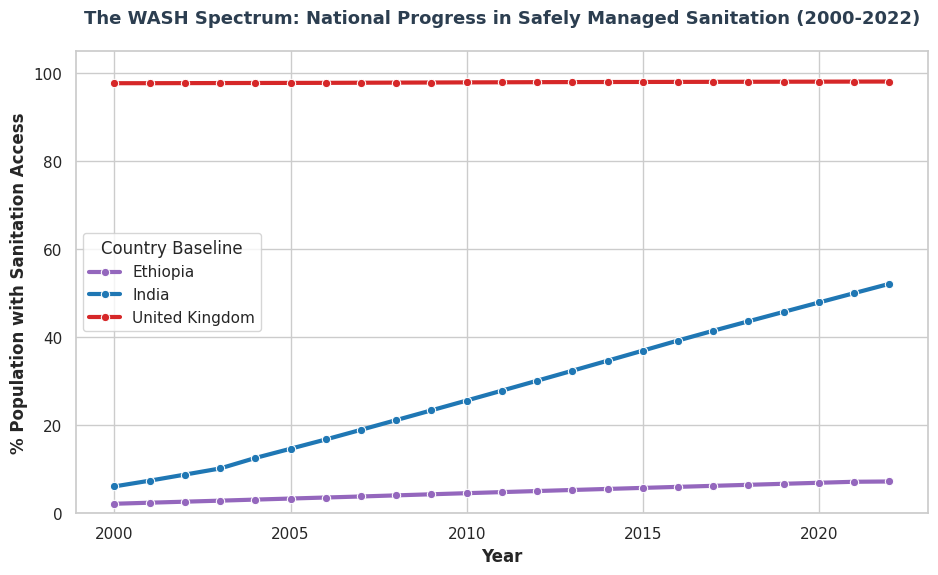

In [35]:
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(
    data=spectrum_df,
    x='Year',
    y='Sanitation_Pct',
    hue='Country',
    linewidth=3,
    marker='o',
    palette={'United Kingdom': '#d62728', 'India': '#1f77b4', 'Ethiopia': '#9467bd'}
)
plt.title('The WASH Spectrum: National Progress in Safely Managed Sanitation (2000-2022)',
          fontsize=13, fontweight='bold', pad=20, color='#2c3e50')
plt.ylabel('% Population with Sanitation Access', fontweight='bold')
plt.xlabel('Year', fontweight='bold')
plt.ylim(0, 105)
plt.legend(title='Country Baseline', loc='best')

plt.savefig('Spectrum_Sanitation_Trends.png', dpi=300)
plt.show()

In [36]:
india_df = df[df['Country'] == 'India'].dropna(subset=['Sanitation_Pct', 'Hygiene_Pct']).copy()

In [42]:
india_melted = india_df.melt(
    id_vars=['Year'],
    value_vars=['Sanitation_Pct', 'Hygiene_Pct'],
    var_name='Metric',
    value_name='Percentage'
)

In [43]:
india_melted['Metric'] = india_melted['Metric'].replace({
    'Sanitation_Pct': 'Safely Managed Sanitation',
    'Hygiene_Pct': 'Basic Hygiene (Soap & Water)'
})

In [44]:
india_melted.head()

,Year,Metric,Percentage
0,2010,Safely Managed Sanitation,25.619543
1,2011,Safely Managed Sanitation,27.863255
2,2012,Safely Managed Sanitation,30.119352
3,2013,Safely Managed Sanitation,32.387146
4,2014,Safely Managed Sanitation,34.665985


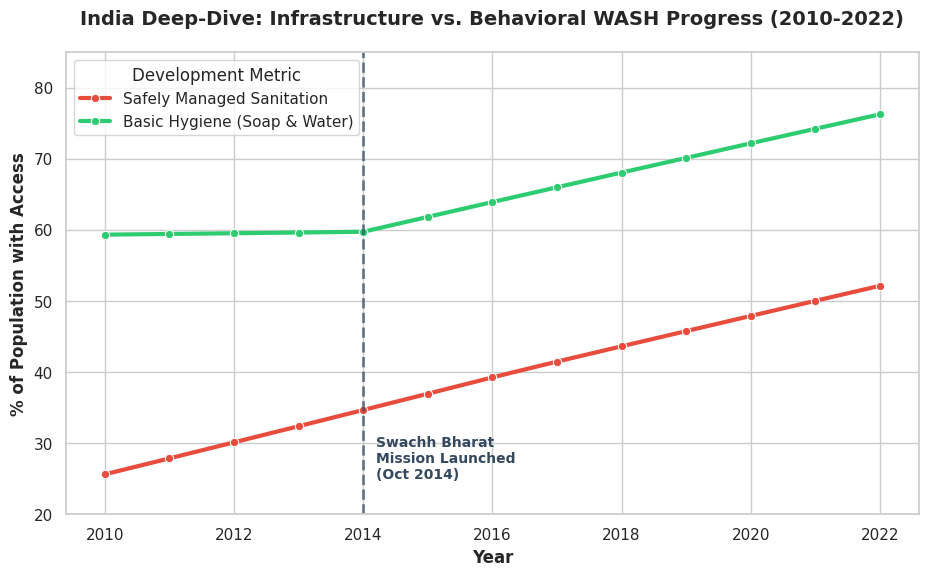

In [55]:
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(
    data=india_melted,
    x='Year',
    y='Percentage',
    hue='Metric',
    linewidth=3,
    marker='o',
    palette={'Safely Managed Sanitation': '#e74c3c', 'Basic Hygiene (Soap & Water)': '#2ecc71'}
)
plt.axvline(x=2014, color='#34495e', linestyle='--', linewidth=2, alpha=0.7)
plt.text(2014.2, 25, 'Swachh Bharat\nMission Launched\n(Oct 2014)',
         color='#34495e', fontweight='bold', fontsize=10)
plt.title('India Deep-Dive: Infrastructure vs. Behavioral WASH Progress (2010-2022)',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('% of Population with Access', fontweight='bold')
plt.xlabel('Year', fontweight='bold')
plt.ylim(20, 85)
plt.legend(title='Development Metric', loc='upper left')
plt.savefig('India_Policy_Impact.png', dpi=300)
plt.show()